正在加载数据: E:\stock\csv_version\analysis_results\000001.SZ_analysis.csv
数据形状: (300, 52)
数据列: ['trade_date', 'ts_code', 'open', 'high', 'low', 'close', 'change', 'volume', 'diff', 'dea', 'macd', 'ma5', 'ma8', 'ma13', 'ma21', 'ma34', 'ma55', 'vr', 'tsma5', 'tsma8', 'tsma13', 'er', 'var', 'sma', 'std', 'upper', 'lower', 'up_mark', 'down_mark', 'shadow_ratio', 'wr5', 'wr55', 'ma_trend_change_win1', 'ma_trend_change_win2', 'cross_events', 'divergence_status', 'divergence_status_macd', 'divergence_status_vr', 'divergence_status_wr5', 'trend_direction', 'is_range', 'support', 'resistance', 'range_start', 'range_end', 'start_type', 'end_type', 'wave_number', 'move_type', 'subwaves', 'target', 'future_5d_return']
前5行数据:
   trade_date    ts_code   open   high    low  close  change      volume  \
0  2020-08-06  000001.SZ  13.82  13.96  13.65  13.90    0.14  1352510.68   
1  2020-08-07  000001.SZ  13.80  13.90  13.62  13.70   -0.20   988678.37   
2  2020-08-10  000001.SZ  13.67  14.02  13.62  13.95  

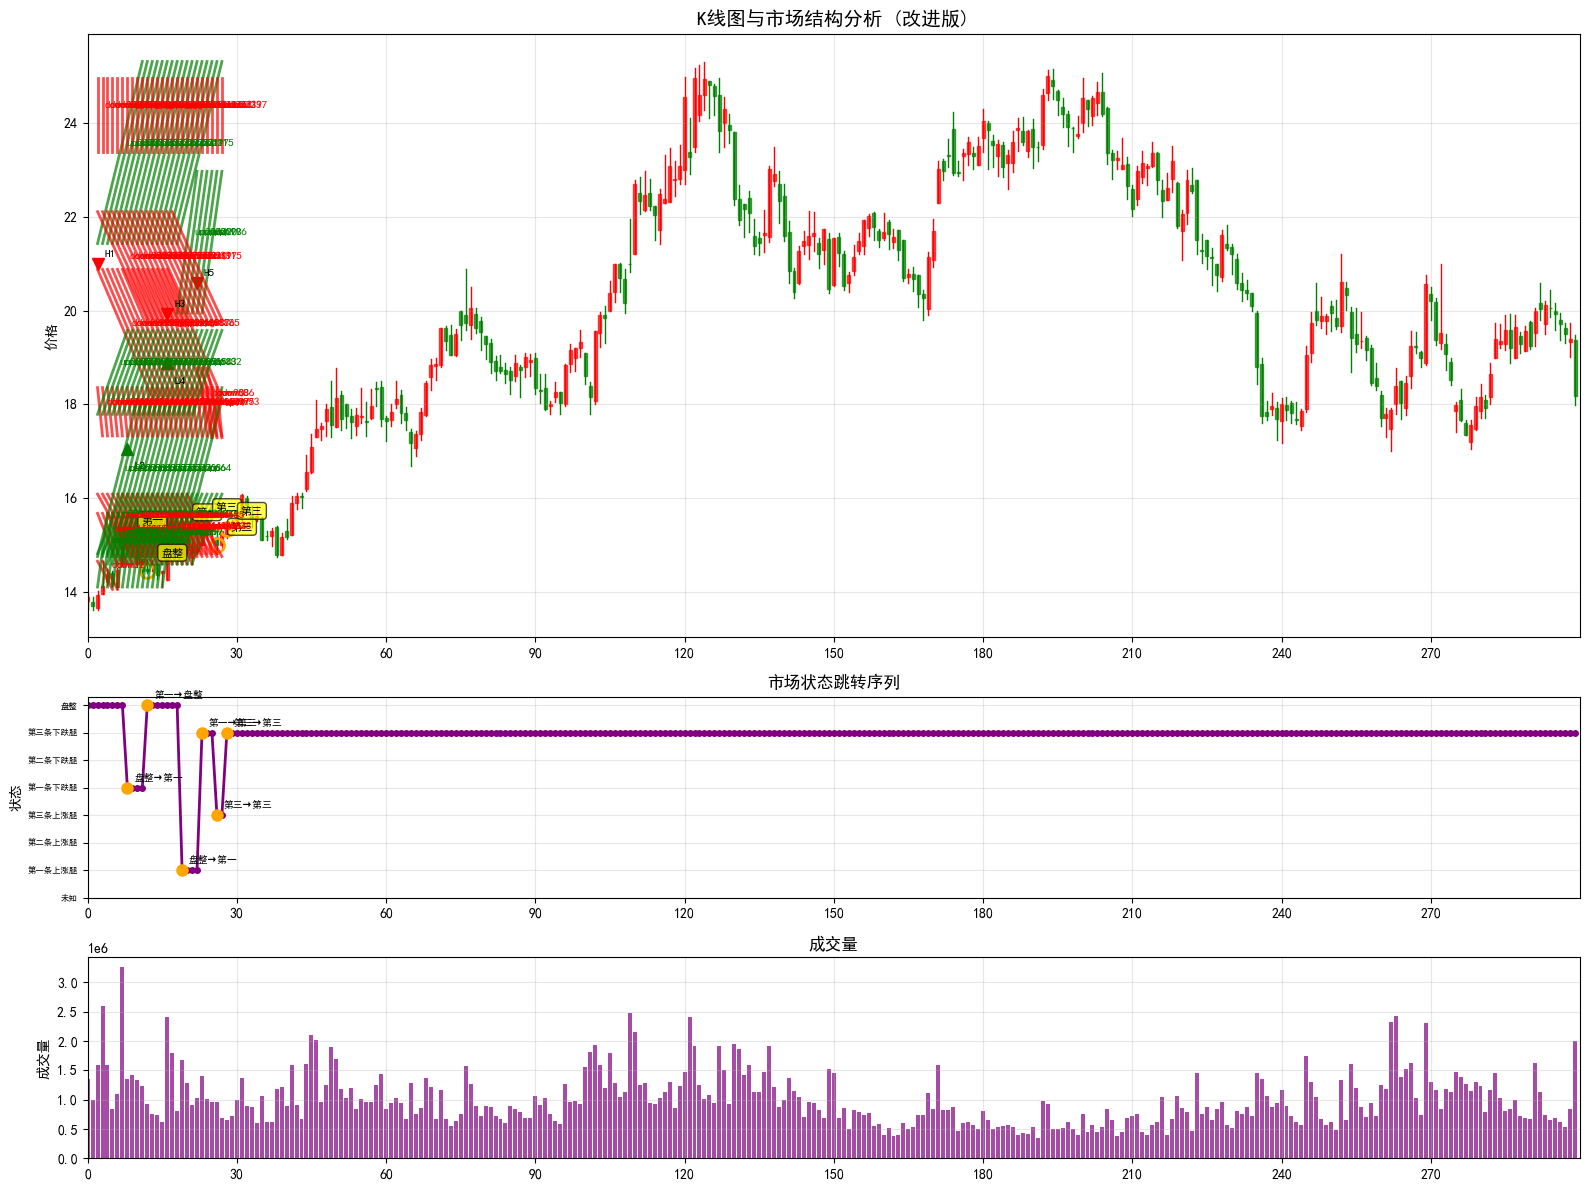


所有分析结果已保存到目录: structure_test_results


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Rectangle
from scipy.signal import argrelextrema
import os
import json
from datetime import datetime
from enum import Enum
from dataclasses import dataclass
from typing import List, Dict, Tuple, Optional, Any
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

class MarketState(Enum):
    """市场状态枚举"""
    UNKNOWN = "未知"
    UP_LEG_1 = "第一条上涨腿"
    UP_LEG_2 = "第二条上涨腿"
    UP_LEG_3 = "第三条上涨腿"
    DOWN_LEG_1 = "第一条下跌腿"
    DOWN_LEG_2 = "第二条下跌腿"
    DOWN_LEG_3 = "第三条下跌腿"
    CONSOLIDATION = "盘整"

@dataclass
class KLine:
    """K线数据结构"""
    open: float
    close: float
    high: float
    low: float
    timestamp: datetime = None
    volume: float = 0.0
    
    @property
    def body_length(self) -> float:
        return abs(self.close - self.open)
    
    @property
    def total_length(self) -> float:
        return self.high - self.low

# ==================== 全局高低点检测算法 ====================

def detect_high_low_points_global(df, window=5):
    """
    全局高低点检测算法 - 在整个数据集上检测
    """
    if 'high' not in df.columns or 'low' not in df.columns:
        raise ValueError("DataFrame必须包含'high'和'low'列")
    
    high_prices = df['high'].values
    low_prices = df['low'].values
    
    # 检测高点和低点
    high_indices = argrelextrema(high_prices, np.greater, order=window)[0]
    low_indices = argrelextrema(low_prices, np.less, order=window)[0]
    
    df = df.copy()
    df['is_high'] = False
    df['is_low'] = False
    df['is_extreme_high'] = False
    df['is_extreme_low'] = False
    
    # 标记所有检测到的高低点
    df.loc[df.index[high_indices], 'is_high'] = True
    df.loc[df.index[low_indices], 'is_low'] = True
    
    # 改进的极值点检测 - 在整个数据集上找重要转折点
    for i in range(1, len(high_indices)-1):
        idx = high_indices[i]
        prev_idx = high_indices[i-1]
        next_idx = high_indices[i+1]
        
        # 如果当前高点比前后高点都高，且变化幅度足够大
        if (high_prices[idx] > high_prices[prev_idx] and 
            high_prices[idx] > high_prices[next_idx] and
            abs(high_prices[idx] - high_prices[prev_idx]) / high_prices[prev_idx] > 0.005):
            df.loc[df.index[idx], 'is_extreme_high'] = True
    
    for i in range(1, len(low_indices)-1):
        idx = low_indices[i]
        prev_idx = low_indices[i-1]
        next_idx = low_indices[i+1]
        
        if (low_prices[idx] < low_prices[prev_idx] and 
            low_prices[idx] < low_prices[next_idx] and
            abs(low_prices[idx] - low_prices[prev_idx]) / low_prices[prev_idx] > 0.005):
            df.loc[df.index[idx], 'is_extreme_low'] = True
    
    # 确保至少有一些极值点被标记
    if not df['is_extreme_high'].any():
        # 如果没有极高点，标记最高的几个点
        top_highs = df.nlargest(3, 'high').index
        df.loc[top_highs, 'is_extreme_high'] = True
    
    if not df['is_extreme_low'].any():
        # 如果没有极低点，标记最低的几个点
        top_lows = df.nsmallest(3, 'low').index
        df.loc[top_lows, 'is_extreme_low'] = True
    
    return df

# ==================== 全局结构分析器 ====================

class GlobalStructuralAnalyzer:
    """全局结构分析器 - 在整个数据集上分析"""
    
    def __init__(self, detection_window=5):
        self.detection_window = detection_window
        self.klines = []
        self.df_global = None
        self.swing_points = []
        self.trend_legs = []
        self.leg_count = {'up': 0, 'down': 0}
    
    def set_data(self, klines, df):
        """设置全局数据"""
        self.klines = klines
        self.df_global = df.copy()
        return self.analyze_global_structure()
    
    def analyze_global_structure(self):
        """分析全局市场结构"""
        if self.df_global is None or len(self.df_global) < 10:
            return {'state': MarketState.CONSOLIDATION}
        
        print("开始全局结构分析...")
        
        # 1. 全局高低点检测
        self._detect_global_extremes()
        
        # 2. 全局趋势腿识别
        self._identify_global_trend_legs()
        
        # 3. 确定当前状态
        current_state = self._determine_current_state()
        
        print(f"全局分析完成: 找到{len(self.swing_points)}个极值点, {len(self.trend_legs)}个趋势腿")
        
        return {
            'state': current_state,
            'swing_points': self.swing_points.copy(),
            'trend_legs': self.trend_legs.copy(),
            'current_price': self.klines[-1].close if self.klines else 0,
            'timestamp': self.klines[-1].timestamp if self.klines else None,
            'current_index': len(self.klines) - 1 if self.klines else 0
        }
    
    def _detect_global_extremes(self):
        """全局极值点检测"""
        df_with_extremes = detect_high_low_points_global(self.df_global, window=self.detection_window)
        
        self.swing_points = []
        
        # 提取极高点
        extreme_highs = df_with_extremes[df_with_extremes['is_extreme_high']]
        for idx, row in extreme_highs.iterrows():
            # 获取数值索引位置
            if isinstance(self.df_global.index, pd.RangeIndex):
                index_pos = idx
            else:
                index_pos = self.df_global.index.get_loc(idx)
            
            self.swing_points.append({
                'index': index_pos,
                'price': row['high'],
                'type': 'high',
                'is_extreme': True,
                'timestamp': idx if isinstance(idx, datetime) else None
            })
        
        # 提取极低点
        extreme_lows = df_with_extremes[df_with_extremes['is_extreme_low']]
        for idx, row in extreme_lows.iterrows():
            if isinstance(self.df_global.index, pd.RangeIndex):
                index_pos = idx
            else:
                index_pos = self.df_global.index.get_loc(idx)
            
            self.swing_points.append({
                'index': index_pos,
                'price': row['low'],
                'type': 'low',
                'is_extreme': True,
                'timestamp': idx if isinstance(idx, datetime) else None
            })
        
        # 按索引排序
        self.swing_points.sort(key=lambda x: x['index'])
        print(f"找到 {len(extreme_highs)} 个极高点和 {len(extreme_lows)} 个极低点")
    
    def _identify_global_trend_legs(self):
        """全局趋势腿识别"""
        if len(self.swing_points) < 2:
            print("极值点不足，无法识别趋势腿")
            return
        
        # 按索引排序
        sorted_points = sorted(self.swing_points, key=lambda x: x['index'])
        
        # 识别所有可能的趋势腿
        potential_legs = []
        for i in range(len(sorted_points)):
            for j in range(i+1, len(sorted_points)):
                prev = sorted_points[i]
                curr = sorted_points[j]
                
                # 确保交替出现高低点
                if prev['type'] == curr['type']:
                    continue
                
                # 计算价格变化
                price_change = abs(curr['price'] - prev['price'])
                avg_price = (prev['price'] + curr['price']) / 2
                change_ratio = price_change / avg_price if avg_price > 0 else 0
                
                # 设置合理的阈值
                if change_ratio < 0.003:  # 0.3%的最小变化
                    continue
                
                # 确定腿的类型
                if prev['type'] == 'low' and curr['type'] == 'high':
                    leg_type = 'up'
                elif prev['type'] == 'high' and curr['type'] == 'low':
                    leg_type = 'down'
                else:
                    continue
                
                leg = {
                    'type': leg_type,
                    'start_index': prev['index'],
                    'end_index': curr['index'],
                    'start_price': prev['price'],
                    'end_price': curr['price'],
                    'height': price_change,
                    'ratio': change_ratio,
                    'length': curr['index'] - prev['index']
                }
                potential_legs.append(leg)
        
        # 筛选有效的趋势腿（避免重叠和过短的腿）
        potential_legs.sort(key=lambda x: x['length'], reverse=True)
        
        self.trend_legs = []
        used_indices = set()
        
        for leg in potential_legs:
            # 检查是否与已选腿重叠
            overlap = False
            for used_leg in self.trend_legs:
                if (leg['start_index'] <= used_leg['end_index'] and 
                    leg['end_index'] >= used_leg['start_index']):
                    overlap = True
                    break
            
            if not overlap and leg['start_index'] not in used_indices and leg['end_index'] not in used_indices:
                leg['number'] = len([l for l in self.trend_legs if l['type'] == leg['type']]) + 1
                self.trend_legs.append(leg)
                used_indices.add(leg['start_index'])
                used_indices.add(leg['end_index'])
        
        # 按开始索引排序
        self.trend_legs.sort(key=lambda x: x['start_index'])
        
        # 为同类型的腿编号
        up_count, down_count = 1, 1
        for leg in self.trend_legs:
            if leg['type'] == 'up':
                leg['number'] = up_count
                up_count += 1
            else:
                leg['number'] = down_count
                down_count += 1
        
        print(f"识别到 {len(self.trend_legs)} 个趋势腿")
        for leg in self.trend_legs:
            print(f"  {leg['type']}腿{leg['number']}: 索引{leg['start_index']}-{leg['end_index']}, "
                  f"变化{leg['ratio']:.2%}")
    
    def _determine_current_state(self):
        """确定当前市场状态"""
        if not self.trend_legs or not self.klines:
            return MarketState.CONSOLIDATION
        
        current_index = len(self.klines) - 1
        
        # 找到包含当前点的最新趋势腿
        current_leg = None
        for leg in reversed(self.trend_legs):
            if leg['start_index'] <= current_index <= leg['end_index']:
                current_leg = leg
                break
        
        if current_leg is None:
            # 检查是否在最后一个腿之后
            last_leg = self.trend_legs[-1]
            if current_index > last_leg['end_index'] and current_index - last_leg['end_index'] <= 10:
                current_leg = last_leg
        
        if current_leg:
            if current_leg['type'] == 'up':
                if current_leg['number'] == 1:
                    return MarketState.UP_LEG_1
                elif current_leg['number'] == 2:
                    return MarketState.UP_LEG_2
                else:
                    return MarketState.UP_LEG_3
            else:
                if current_leg['number'] == 1:
                    return MarketState.DOWN_LEG_1
                elif current_leg['number'] == 2:
                    return MarketState.DOWN_LEG_2
                else:
                    return MarketState.DOWN_LEG_3
        
        return MarketState.CONSOLIDATION

# ==================== 改进的状态跳转测试器 ====================

class StateTransitionTester:
    """改进的状态跳转测试器"""
    
    def __init__(self):
        self.current_state = MarketState.CONSOLIDATION
        self.state_history = []
        self.transition_log = []
        self.min_state_duration = 3
        self.last_state_change_index = 0
    
    def determine_next_state(self, structure_analysis):
        """确定下一个状态"""
        new_state = structure_analysis.get('state', MarketState.CONSOLIDATION)
        current_index = structure_analysis.get('current_index', 0)
        
        should_change = self._should_change_state(new_state, current_index)
        
        old_state = self.current_state
        
        if should_change:
            self.current_state = new_state
            self.last_state_change_index = current_index
            
            transition_info = {
                'timestamp': structure_analysis.get('timestamp'),
                'from_state': old_state,
                'to_state': new_state,
                'price': structure_analysis.get('current_price', 0),
                'index': current_index
            }
            
            self.state_history.append(new_state)
            self.transition_log.append(transition_info)
            print(f"状态跳转: {old_state.value} -> {new_state.value} (索引={current_index})")
            
            return new_state, transition_info
        else:
            return old_state, {
                'timestamp': structure_analysis.get('timestamp'),
                'from_state': old_state,
                'to_state': old_state,
                'price': structure_analysis.get('current_price', 0),
                'index': current_index
            }
    
    def _should_change_state(self, new_state, current_index):
        """判断是否应该改变状态"""
        if new_state == self.current_state:
            return False
        
        if current_index - self.last_state_change_index < self.min_state_duration:
            return False
        
        return True

# ==================== 全局市场结构测试器 ====================

class GlobalMarketStructureTester:
    """全局市场结构测试器"""
    
    def __init__(self, csv_file_path, output_dir="structure_test_results"):
        self.csv_file_path = csv_file_path
        self.output_dir = output_dir
        self.klines = []
        self.df = None
        self.global_analyzer = GlobalStructuralAnalyzer(detection_window=5)
        self.state_tester = StateTransitionTester()
        self.analysis_results = []
        
        os.makedirs(output_dir, exist_ok=True)
    
    def load_data(self):
        """加载数据"""
        print(f"正在加载数据: {self.csv_file_path}")
        
        try:
            # 读取更多数据以便有足够的数据点
            self.df = pd.read_csv(self.csv_file_path, nrows=500)
            
            print(f"数据形状: {self.df.shape}")
            print(f"数据列: {self.df.columns.tolist()}")
            print(f"价格范围: {self.df['high'].max():.4f} - {self.df['low'].min():.4f}")
            
            # 尝试解析时间列
            time_columns = ['timestamp', 'time', 'trade_date', 'datetime', 'date']
            time_col = None
            for col in time_columns:
                if col in self.df.columns:
                    time_col = col
                    break
            
            if time_col:
                try:
                    self.df[time_col] = pd.to_datetime(self.df[time_col])
                    self.df = self.df.set_index(time_col)
                    print(f"使用时间列: {time_col}")
                except:
                    print(f"时间列解析失败，使用索引作为时间")
                    self.df.index = pd.RangeIndex(start=0, stop=len(self.df))
            else:
                self.df.index = pd.RangeIndex(start=0, stop=len(self.df))
            
            # 确保必要的列存在
            required_columns = ['open', 'high', 'low', 'close']
            for col in required_columns:
                if col not in self.df.columns:
                    col_lower = col.lower()
                    matching_cols = [c for c in self.df.columns if c.lower() == col_lower]
                    if matching_cols:
                        self.df[col] = self.df[matching_cols[0]]
                    else:
                        raise ValueError(f"缺少必要列: {col}")
            
            # 创建K线对象
            self.klines = []
            for idx, row in self.df.iterrows():
                kline = KLine(
                    open=float(row['open']),
                    high=float(row['high']),
                    low=float(row['low']),
                    close=float(row['close']),
                    volume=float(row.get('volume', 0)),
                    timestamp=idx if isinstance(idx, datetime) else None
                )
                self.klines.append(kline)
            
            print(f"成功加载 {len(self.klines)} 根K线数据")
            return True
            
        except Exception as e:
            print(f"数据加载失败: {e}")
            import traceback
            traceback.print_exc()
            return False
    
    def run_analysis(self):
        """运行分析"""
        if not self.klines:
            print("没有可分析的数据")
            return
        
        print("开始全局市场结构分析...")
        
        # 首先进行全局分析
        global_analysis = self.global_analyzer.set_data(self.klines, self.df)
        
        # 然后模拟实时分析过程
        for i, kline in enumerate(self.klines):
            # 使用全局分析结果，但根据当前索引确定状态
            current_state = self._get_state_at_index(i, global_analysis)
            
            # 状态跳转分析
            analysis_for_index = {
                'state': current_state,
                'current_price': kline.close,
                'timestamp': kline.timestamp,
                'current_index': i
            }
            
            new_state, transition_info = self.state_tester.determine_next_state(analysis_for_index)
            
            result = {
                'index': i,
                'timestamp': kline.timestamp,
                'price': kline.close,
                'structure': global_analysis,  # 使用全局分析结果
                'state': new_state,
                'transition_info': transition_info
            }
            self.analysis_results.append(result)
            
            if (i + 1) % 50 == 0:
                print(f"已分析 {i + 1} 根K线")
        
        print("分析完成!")
    
    def _get_state_at_index(self, index, global_analysis):
        """根据索引获取对应的状态"""
        trend_legs = global_analysis.get('trend_legs', [])
        
        # 找到包含当前索引的趋势腿
        for leg in trend_legs:
            if leg['start_index'] <= index <= leg['end_index']:
                if leg['type'] == 'up':
                    if leg['number'] == 1:
                        return MarketState.UP_LEG_1
                    elif leg['number'] == 2:
                        return MarketState.UP_LEG_2
                    else:
                        return MarketState.UP_LEG_3
                else:
                    if leg['number'] == 1:
                        return MarketState.DOWN_LEG_1
                    elif leg['number'] == 2:
                        return MarketState.DOWN_LEG_2
                    else:
                        return MarketState.DOWN_LEG_3
        
        # 如果不在任何趋势腿中，检查是否接近某个腿的结束点
        for leg in trend_legs:
            if index > leg['end_index'] and index - leg['end_index'] <= 5:
                if leg['type'] == 'up':
                    return MarketState.UP_LEG_3  # 假设上涨腿结束后进入盘整或下跌
                else:
                    return MarketState.DOWN_LEG_3  # 假设下跌腿结束后进入盘整或上涨
        
        return MarketState.CONSOLIDATION
    
    def save_transition_log(self):
        """保存状态跳转日志"""
        log_file = os.path.join(self.output_dir, "state_transitions.json")
        
        log_data = {
            'analysis_summary': {
                'total_klines': len(self.klines),
                'total_transitions': len(self.state_tester.transition_log),
                'final_state': self.state_tester.current_state.value,
                'unique_states': len(set(self.state_tester.state_history))
            },
            'transitions': []
        }
        
        for transition in self.state_tester.transition_log:
            log_data['transitions'].append({
                'timestamp': str(transition['timestamp']) if transition['timestamp'] else f"Index_{transition['index']}",
                'from_state': transition['from_state'].value,
                'to_state': transition['to_state'].value,
                'price': round(transition['price'], 4),
                'index': transition['index']
            })
        
        with open(log_file, 'w', encoding='utf-8') as f:
            json.dump(log_data, f, ensure_ascii=False, indent=2)
        
        print(f"状态跳转日志已保存到: {log_file}")
        self._print_transition_summary(log_data)
    
    def _print_transition_summary(self, log_data):
        """打印状态跳转摘要"""
        print("\n" + "="*80)
        print("状态跳转分析摘要")
        print("="*80)
        
        summary = log_data['analysis_summary']
        print(f"总K线数量: {summary['total_klines']}")
        print(f"状态跳转次数: {summary['total_transitions']}")
        print(f"最终状态: {summary['final_state']}")
        print(f"出现过的状态种类: {summary['unique_states']}")
        
        state_counts = {}
        for transition in log_data['transitions']:
            state = transition['to_state']
            state_counts[state] = state_counts.get(state, 0) + 1
        
        print("\n各状态出现频率:")
        for state, count in sorted(state_counts.items(), key=lambda x: x[1], reverse=True):
            percentage = (count / len(log_data['transitions'])) * 100 if log_data['transitions'] else 0
            print(f"  {state}: {count}次 ({percentage:.1f}%)")
        
        print(f"\n所有状态跳转:")
        for i, trans in enumerate(log_data['transitions']):
            print(f"  {i+1}. {trans['from_state']} → {trans['to_state']} "
                  f"(索引={trans['index']}, 价格={trans['price']})")
    
    def plot_comprehensive_analysis(self):
        """绘制综合分析图表"""
        if len(self.analysis_results) < 5:
            print("数据不足，无法绘制图表")
            return
        
        print("正在生成全局综合分析图表...")
        
        fig = plt.figure(figsize=(18, 14))
        gs = fig.add_gridspec(3, 1, height_ratios=[3, 1, 1])
        
        ax1 = fig.add_subplot(gs[0])
        self._plot_kline_and_global_structure(ax1)
        
        ax2 = fig.add_subplot(gs[1], sharex=ax1)
        self._plot_state_transitions(ax2)
        
        ax3 = fig.add_subplot(gs[2], sharex=ax1)
        self._plot_volume(ax3)
        
        plt.tight_layout()
        
        chart_file = os.path.join(self.output_dir, "global_analysis.png")
        plt.savefig(chart_file, dpi=300, bbox_inches='tight')
        print(f"全局综合分析图表已保存到: {chart_file}")
        
        plt.show()
    
    def _plot_kline_and_global_structure(self, ax):
        """绘制K线图和全局结构分析"""
        # 绘制K线
        for i in range(len(self.df)):
            row = self.df.iloc[i]
            color = 'red' if row['close'] > row['open'] else 'green'
            ax.plot([i, i], [row['low'], row['high']], color=color, linewidth=1)
            rect = Rectangle((i-0.3, min(row['open'], row['close'])), 0.6, 
                            abs(row['close']-row['open']), 
                            facecolor=color, alpha=0.7, edgecolor=color)
            ax.add_patch(rect)
        
        # 使用全局分析结果
        global_analysis = self.global_analyzer.analyze_global_structure()
        swing_points = global_analysis.get('swing_points', [])
        trend_legs = global_analysis.get('trend_legs', [])
        
        print(f"绘图: 找到{len(swing_points)}个极值点, {len(trend_legs)}个趋势腿")
        
        # 标注所有极值点
        high_points = [p for p in swing_points if p['type'] == 'high']
        low_points = [p for p in swing_points if p['type'] == 'low']
        
        for i, point in enumerate(high_points):
            ax.plot(point['index'], point['price'], 'v', color='red', markersize=10,
                   markerfacecolor='red', markeredgecolor='darkred', markeredgewidth=2)
            ax.annotate(f"H{i+1}", (point['index'], point['price']), 
                       xytext=(8, 8), textcoords='offset points', 
                       fontsize=9, color='red', weight='bold',
                       bbox=dict(boxstyle="round,pad=0.2", fc="lightcoral", alpha=0.7))
        
        for i, point in enumerate(low_points):
            ax.plot(point['index'], point['price'], '^', color='green', markersize=10,
                   markerfacecolor='green', markeredgecolor='darkgreen', markeredgewidth=2)
            ax.annotate(f"L{i+1}", (point['index'], point['price']), 
                       xytext=(8, -15), textcoords='offset points', 
                       fontsize=9, color='green', weight='bold',
                       bbox=dict(boxstyle="round,pad=0.2", fc="lightgreen", alpha=0.7))
        
        # 标注状态跳转点
        for result in self.analysis_results:
            if result['transition_info']['from_state'] != result['transition_info']['to_state']:
                ax.plot(result['index'], result['price'], 'o', color='orange', markersize=12,
                       markerfacecolor='none', markeredgewidth=3, markeredgecolor='orange')
                state_name = result['state'].value[:2]
                ax.annotate(state_name, (result['index'], result['price']), 
                           xytext=(12, 12), textcoords='offset points', fontsize=10,
                           bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.8))
        
        # 绘制趋势腿连线
        for leg in trend_legs:
            color = 'green' if leg['type'] == 'up' else 'red'
            linewidth = 3 if leg['ratio'] > 0.01 else 2  # 变化大的腿用粗线
            
            ax.plot([leg['start_index'], leg['end_index']], 
                   [leg['start_price'], leg['end_price']], 
                   color=color, linewidth=linewidth, alpha=0.8, linestyle='-')
            
            # 标注腿的信息
            mid_x = (leg['start_index'] + leg['end_index']) / 2
            mid_y = (leg['start_price'] + leg['end_price']) / 2
            
            leg_label = f"{leg['type']}{leg['number']}({leg['ratio']:.1%})"
            ax.annotate(leg_label, (mid_x, mid_y), 
                       xytext=(10, 10 if leg['type'] == 'up' else -20), 
                       textcoords='offset points',
                       fontsize=10, color=color, weight='bold',
                       bbox=dict(boxstyle="round,pad=0.3", 
                               fc="lightgreen" if leg['type'] == 'up' else "lightcoral", 
                               alpha=0.8))
        
        ax.set_title('全局市场结构分析', fontsize=16, fontweight='bold', pad=20)
        ax.set_ylabel('价格', fontsize=12)
        ax.grid(True, alpha=0.3)
        
        # 设置x轴
        n = len(self.df)
        if n > 0:
            step = max(1, n // 15)  # 显示15个刻度
            ax.set_xticks(range(0, n, step))
            ax.set_xlim(-1, n)
        
        # 添加图例
        from matplotlib.lines import Line2D
        legend_elements = [
            Line2D([0], [0], color='red', lw=2, label='上涨腿'),
            Line2D([0], [0], color='green', lw=2, label='下跌腿'),
            Line2D([0], [0], marker='v', color='red', label='极高点', markersize=8, linestyle='None'),
            Line2D([0], [0], marker='^', color='green', label='极低点', markersize=8, linestyle='None'),
            Line2D([0], [0], marker='o', color='orange', label='状态跳转', markersize=8, linestyle='None', markeredgewidth=2)
        ]
        ax.legend(handles=legend_elements, loc='upper left', fontsize=10)
    
    def _plot_state_transitions(self, ax):
        """绘制状态跳转图"""
        if not self.analysis_results:
            return
            
        states = [r['state'] for r in self.analysis_results]
        state_values = [list(MarketState).index(state) for state in states]
        indices = [r['index'] for r in self.analysis_results]
        
        ax.plot(indices, state_values, 'o-', linewidth=2, markersize=4, color='purple', alpha=0.7)
        
        # 标注状态跳转点
        for i in range(1, len(states)):
            if states[i] != states[i-1]:
                ax.plot(indices[i], state_values[i], 'o', color='orange', markersize=8,
                       markerfacecolor='orange', markeredgecolor='darkorange', markeredgewidth=2)
                ax.annotate(f"{states[i-1].value[:2]}→{states[i].value[:2]}", 
                           (indices[i], state_values[i]), 
                           xytext=(8, 8), textcoords='offset points', fontsize=8,
                           bbox=dict(boxstyle="round,pad=0.2", fc="yellow", alpha=0.7))
        
        ax.set_title('市场状态跳转序列', fontsize=14, fontweight='bold')
        ax.set_ylabel('状态', fontsize=12)
        ax.grid(True, alpha=0.3)
        
        # 设置y轴刻度
        ax.set_yticks(range(len(MarketState)))
        ax.set_yticklabels([s.value for s in MarketState], fontsize=8)
        ax.set_xlim(0, len(self.df))
    
    def _plot_volume(self, ax):
        """绘制成交量图"""
        if 'volume' in self.df.columns and self.df['volume'].sum() > 0:
            volumes = self.df['volume'].values
            ax.bar(range(len(volumes)), volumes, alpha=0.7, color='purple', width=0.8)
            ax.set_title('成交量', fontsize=14, fontweight='bold')
            ax.set_ylabel('成交量', fontsize=12)
        else:
            ax.text(0.5, 0.5, '无成交量数据', ha='center', va='center', 
                   transform=ax.transAxes, fontsize=12)
        
        ax.grid(True, alpha=0.3)
        ax.set_xlim(0, len(self.df))
        ax.set_xlabel('K线索引', fontsize=12)
    
    def generate_detailed_report(self):
        """生成详细分析报告"""
        report_file = os.path.join(self.output_dir, "global_analysis_report.txt")
        
        with open(report_file, 'w', encoding='utf-8') as f:
            f.write("全局市场结构与状态跳转详细分析报告\n")
            f.write("=" * 60 + "\n\n")
            
            f.write(f"分析时间: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
            f.write(f"数据文件: {self.csv_file_path}\n")
            f.write(f"总K线数量: {len(self.klines)}\n")
            f.write(f"价格范围: {self.df['high'].max():.4f} - {self.df['low'].min():.4f}\n\n")
            
            # 全局结构分析统计
            f.write("全局结构分析统计:\n")
            f.write("-" * 25 + "\n")
            
            global_analysis = self.global_analyzer.analyze_global_structure()
            swing_points = global_analysis.get('swing_points', [])
            trend_legs = global_analysis.get('trend_legs', [])
            
            f.write(f"识别到的极值点: {len(swing_points)}\n")
            f.write(f"识别到的趋势腿: {len(trend_legs)}\n\n")
            
            f.write("趋势腿详情:\n")
            for leg in trend_legs:
                f.write(f"  {leg['type']}腿{leg['number']}: 索引{leg['start_index']}-{leg['end_index']}, "
                       f"价格{leg['start_price']:.4f}-{leg['end_price']:.4f}, "
                       f"变化{leg['ratio']:.2%}, 长度{leg['length']}根K线\n")
            f.write("\n")
            
            # 状态分析统计
            f.write("状态分析统计:\n")
            f.write("-" * 25 + "\n")
            
            state_counts = {}
            for result in self.analysis_results:
                state = result['state']
                state_counts[state] = state_counts.get(state, 0) + 1
            
            for state, count in sorted(state_counts.items(), key=lambda x: x[1], reverse=True):
                percentage = (count / len(self.analysis_results)) * 100
                f.write(f"{state.value}: {count}根K线 ({percentage:.1f}%)\n")
            
            f.write(f"\n总状态跳转次数: {len(self.state_tester.transition_log)}\n\n")
            
            # 状态跳转详情
            f.write("状态跳转详情:\n")
            f.write("-" * 35 + "\n")
            
            for i, trans in enumerate(self.state_tester.transition_log):
                f.write(f"{i+1:2d}. 索引{trans['index']:>3d} | "
                       f"{trans['from_state'].value:>10} → {trans['to_state'].value:>10} | "
                       f"价格: {trans['price']:.4f}\n")
        
        print(f"详细分析报告已保存到: {report_file}")

def main():
    """主函数"""
    ts_code = "000001.SZ"
    csv_file = fr'E:\stock\csv_version\analysis_results\{ts_code}_analysis.csv'
    output_directory = "global_structure_test_results"
    
    tester = GlobalMarketStructureTester(csv_file, output_directory)
    
    if not tester.load_data():
        print("数据加载失败，请检查文件路径和格式")
        return
    
    tester.run_analysis()
    tester.save_transition_log()
    tester.generate_detailed_report()
    tester.plot_comprehensive_analysis()
    
    print(f"\n所有分析结果已保存到目录: {output_directory}")

if __name__ == "__main__":
    main()